Add Project Root to sys.path

In [9]:
import sys, os

# Add project root to Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)


Import Libraries    

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from src.analysis_utils import compute_yearly_averages, fit_polynomial_models

Output Table

In [11]:
df = pd.read_csv('../data/retail_and_food_services_adjusted.csv', index_col = 0)
print(df)

         JAN     FEB     MAR     APR     MAY     JUN     JUL     AUG     SEP  \
YEAR                                                                           
1992  159177  159189  158647  159921  160471  161205  162855  162412  164361   
1993  169500  168840  167682  172102  172960  173018  175822  175233  176608   
1994  179615  183101  186721  186423  185616  187800  188062  190771  192585   
1995  195908  193068  195179  195310  198060  200383  199110  201078  201337   
1996  203793  206875  207650  209294  211157  209474  210827  210846  213233   
1997  218124  219587  221189  217925  217771  220233  222985  223120  224509   
1998  225954  225746  226889  230409  230995  233207  231551  229792  232308   
1999  240269  243346  244687  246628  248367  249329  251263  253844  255029   
2000  261545  265686  269019  264067  265992  267750  265683  266885  270523   
2001  272881  272627  269820  274410  275769  274474  273098  275659  268652   
2002  277135  278869  278079  281147  27

Seasonal Adjustments

In [12]:
seasonal_factors = pd.read_csv('../data/retail_and_food_services_seasonal_factors.csv', index_col = 0)
print(seasonal_factors)

EmptyDataError: No columns to parse from file

Create Plot

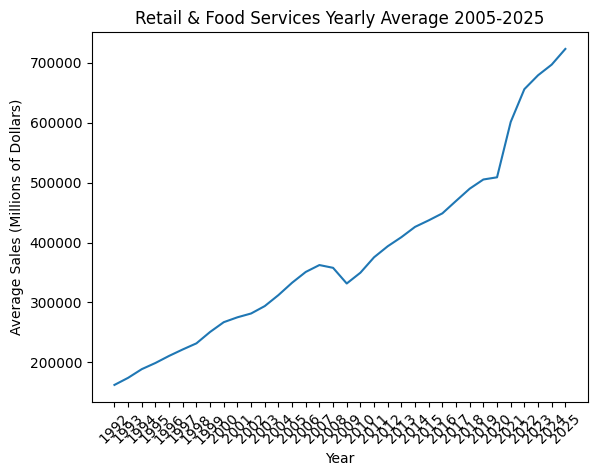

In [ ]:
# This function goes through the rows of the dataframe and finds the average

yearly_averages = compute_yearly_averages(df)


# df.index refers to the years

plt.plot(df.index, yearly_averages)
plt.title("Retail & Food Services Yearly Average 2005-2025")
plt.xlabel("Year")
plt.ylabel("Average Sales (Millions of Dollars)")
plt.xticks(np.arange(1992, 2026, step=1))
plt.xticks(rotation = 45)

plt.show()

Unemployment Data

In [ ]:
# Unemployment rate only from 2005 - 2025
unemployment_df = pd.read_csv('../data/civilian_unemployment_rate.csv', index_col = 0)

# Cleaning the data
columns_to_drop = ['Men_20plus', 'Women_20plus', 'Age_16_19', 'White', 'Black', 'Asian', 'Hispanic'] # Columns not needed

# Take from November only because that's when the census is taken for general merchandise
unemployment_df = unemployment_df[unemployment_df.index.str.startswith('Nov')]
unemployment_df = unemployment_df.drop(columns=columns_to_drop)
 
# Remove the month name from the column
unemployment_df.index = unemployment_df.index.str[4:]
unemployment_df.index = unemployment_df.index.astype(int) # Convert back to integer

print("Civilian Unemployment Data")
print(unemployment_df)

# Update Average Sales CSV to 2005-2025 only
df = df[df.index >= 2005]

yearly_averages = []

for year in df.index:
    average = df.loc[year].mean()
    yearly_averages.append(average)


# Checking if the data is clean
print("Retail & Food Services Data")
print(df)


Civilian Unemployment Data
       Total
Month       
2005     5.0
2006     4.5
2007     4.7
2008     6.8
2009     9.9
2010     9.8
2011     8.6
2012     7.7
2013     6.9
2014     5.8
2015     5.1
2016     4.7
2017     4.2
2018     3.8
2019     3.6
2020     6.7
2021     4.2
2022     3.6
2023     3.7
2024     4.2
2025     4.6
Retail & Food Services Data
         JAN     FEB     MAR     APR     MAY     JUN     JUL     AUG     SEP  \
YEAR                                                                           
2005  321272  325308  326179  329124  327233  337219  339529  335605  336600   
2006  349664  347021  348357  350072  348889  350795  351916  353285  351240   
2007  355792  356545  359415  358562  363085  360234  361770  363676  365178   
2008  367368  364126  365164  364816  368255  368926  367594  364611  358991   
2009  329787  328376  322634  324323  327011  332227  333670  339586  330998   
2010  339093  339580  346974  349869  346858  346516  347612  349188  352179   
2011  

General Merchandise vs Unemployment Rate Graph

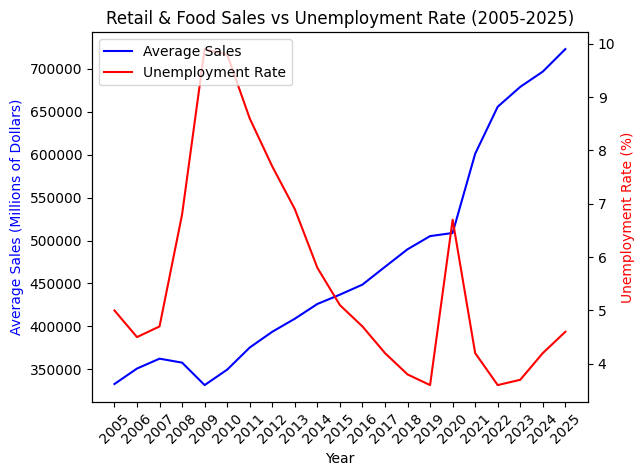

In [ ]:
fig, ax1 = plt.subplots()

# Sales (left axis)
line1, = ax1.plot(df.index, yearly_averages, label="Average Sales", color="blue")
ax1.set_xlabel("Year")
ax1.set_ylabel("Average Sales (Millions of Dollars)", color="blue")
ax1.set_xticks(np.arange(2005, 2026, step=1))
plt.xticks(rotation=45)

# Unemployment (right axis)
ax2 = ax1.twinx()
line2, = ax2.plot(unemployment_df.index, unemployment_df['Total'], label="Unemployment Rate", color="red")
ax2.set_ylabel("Unemployment Rate (%)", color="red")

# Title
plt.title("Retail & Food Sales vs Unemployment Rate (2005-2025)")
plt.legend(handles=[line1, line2], loc="upper left")

plt.show()

General Merchandise vs Inflation Rate Graph

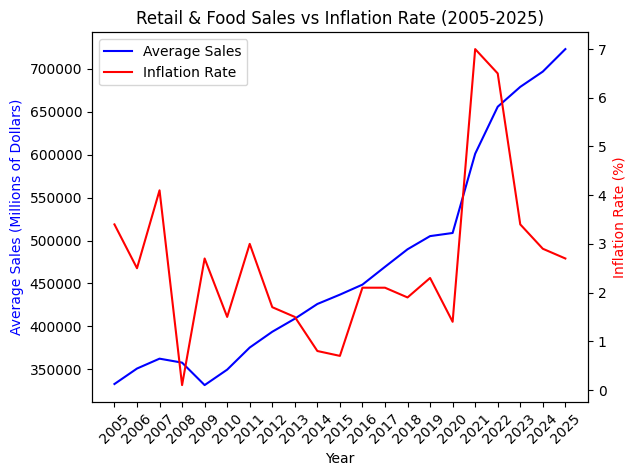

In [ ]:
# Inflation rate data from 2005=2025
inflation_df = pd.read_csv('../data/inflation_rate.csv', index_col = 0)

fig, ax1 = plt.subplots()

# Sales (left axis)
line1, = ax1.plot(df.index, yearly_averages, label="Average Sales", color="blue")
ax1.set_xlabel("Year")
ax1.set_ylabel("Average Sales (Millions of Dollars)", color="blue")
ax1.set_xticks(np.arange(2005, 2026, step=1))
plt.xticks(rotation=45)

# Unemployment (right axis)
ax2 = ax1.twinx()
line2, = ax2.plot(inflation_df.index, inflation_df['Inflation Rate'], label="Inflation Rate", color="red")
ax2.set_ylabel("Inflation Rate (%)", color="red")

# Title
plt.title("Retail & Food Sales vs Inflation Rate (2005-2025)")
plt.legend(handles=[line1, line2], loc="upper left")

plt.show()

Finding the best model for forecasting future trends

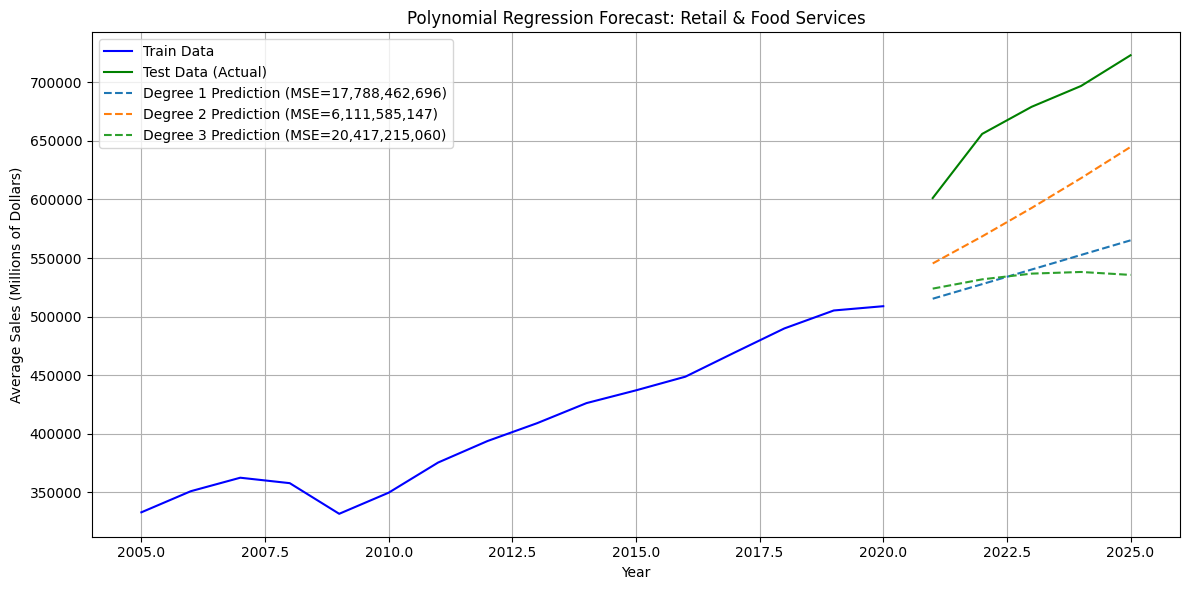

In [ ]:
years = df.index.values.astype(float)
sales = np.array(yearly_averages)

# Scale years for numerical stability
years_scaled = years - years.min()

# Train / test split
train_size = len(years_scaled) - 5

X_train = years_scaled[:train_size]
y_train = sales[:train_size]

X_test = years_scaled[train_size:]
y_test = sales[train_size:]   

polynomials, mse_values, predictions, chi2_values, bic_values = fit_polynomial_models(X_train, y_train, X_test, y_test)

plt.figure(figsize=(12, 6))

# Train data
plt.plot(years[:train_size], y_train, label="Train Data", color="blue")

# Test data (actual)
plt.plot(years[train_size:], y_test, label="Test Data (Actual)", color="green")

# Predictions
for order, model in polynomials.items():
    plt.plot(
        years[train_size:],
        predictions[order],
        linestyle="--",
        label=f"Degree {order} Prediction (MSE={mse_values[order]:,.0f})"
    )


plt.title("Polynomial Regression Forecast: Retail & Food Services")
plt.xlabel("Year")
plt.ylabel("Average Sales (Millions of Dollars)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


MSE, BIC, χ²/DoF Comparison

In [ ]:
# Creates a table comparing the different statistial values

comparison_df = pd.DataFrame({
    "Order": list(mse_values.keys()),
    "MSE": list(mse_values.values()),
    "Chi²/DoF": list(chi2_values.values()),
    "BIC": list(bic_values.values())
})

comparison_df = comparison_df.sort_values("Order")
comparison_df


,Order,MSE,Chi²/DoF,BIC
0,1,1.778846e+10,2.964744e+10,121.227955
1,2,6.111585e+09,1.527896e+10,117.495574
2,3,2.041722e+10,1.020861e+11,125.135973


BIC vs Polynomial Order

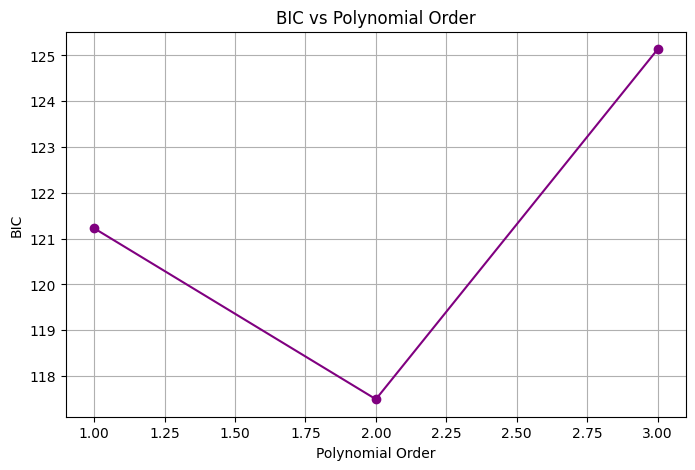

In [ ]:
# Compares the Bayesian Information Criterion to the order number

plt.figure(figsize=(8, 5))
plt.plot(list(bic_values.keys()), list(bic_values.values()), marker='o', color='purple')
plt.title("BIC vs Polynomial Order")
plt.xlabel("Polynomial Order")
plt.ylabel("BIC")
plt.grid(True)
plt.show()


χ²/DoF vs Polynomial Order

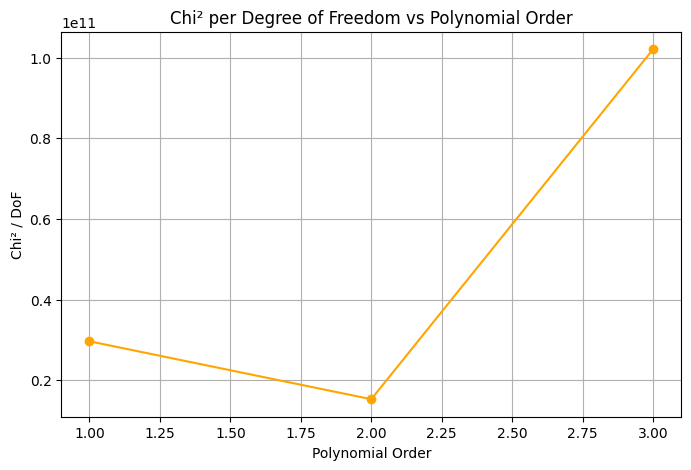

In [ ]:
# Compares chi-squared/Degree of Freedom to the order number 

plt.figure(figsize=(8, 5))
plt.plot(list(chi2_values.keys()), list(chi2_values.values()), marker='o', color='orange')
plt.title("Chi² per Degree of Freedom vs Polynomial Order")
plt.xlabel("Polynomial Order")
plt.ylabel("Chi² / DoF")
plt.grid(True)
plt.show()


Forecast Future Sales (2026-2030)

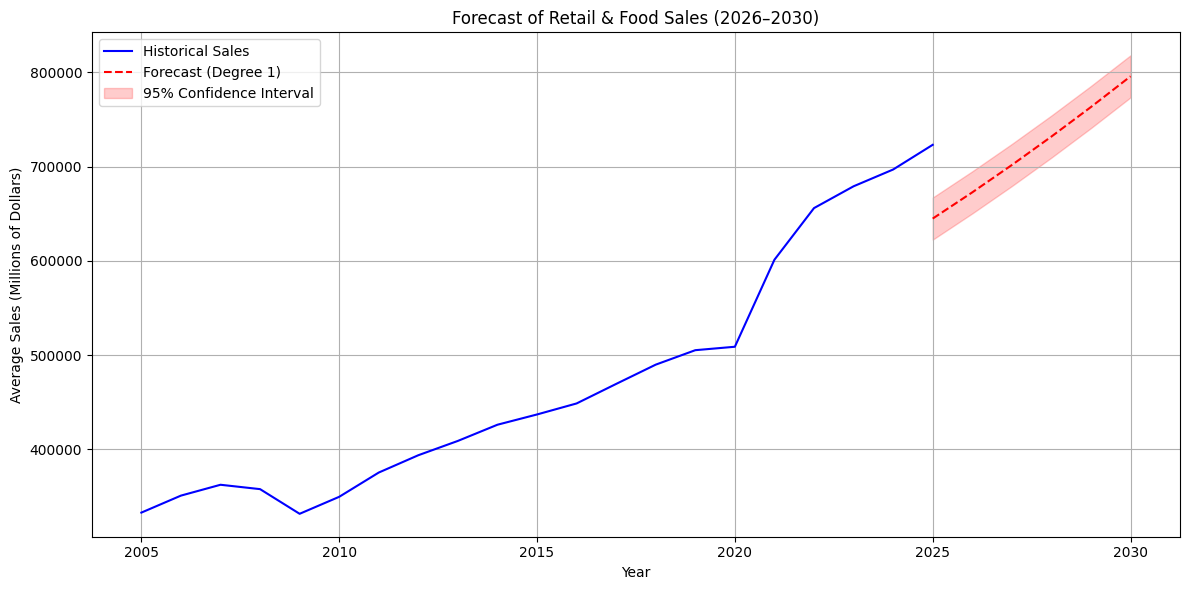

In [ ]:

# Order 2 gave the best results (lowest chi-squred + most accurate on graph)
best_order = 2
model = polynomials[best_order]

# Include 2025 to stop any gaps in graphs
future_years = np.array([2025, 2026, 2027, 2028, 2029, 2030])
future_scaled = future_years - years.min()
future_preds =  model(future_scaled)

residuals = y_test - predictions[best_order]
std_error = np.std(residuals)

# 95% Confidence Intervals

upper_bound = future_preds + 1.96 * std_error
lower_bound = future_preds - 1.96 * std_error

plt.figure(figsize=(12, 6))

# Historical data
plt.plot(years, sales, label="Historical Sales", color="blue")

# Forecast
plt.plot(future_years, future_preds, label="Forecast (Degree 1)", color="red", linestyle="--")

# Confidence interval shading
plt.fill_between(future_years, lower_bound, upper_bound, color="red", alpha=0.2, label="95% Confidence Interval")

plt.title("Forecast of Retail & Food Sales (2026–2030)")
plt.xlabel("Year")
plt.ylabel("Average Sales (Millions of Dollars)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
